# Loading Packages

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from scipy.optimize import nnls
import os.path as osp
# plt.style.use('dark_background')
plt.rcParams['font.size'] = 16

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# Some Rotational Calculations

In [2]:
# ─── Rigid-rotor model ───────────────────────────────────────────────────────
# Assumption 1 (rigid rotor): the molecule is treated as a rigid body.
# Centrifugal distortion (bond stretching at high J) is ignored.  For large
# PAHs this is safe because the centrifugal correction D_J * J^4 << B * J^2
# for the J values that dominate the thermal distribution. We 
#
# For a linear or symmetric-top molecule the energy levels are exactly:
#   E_J = hcB J(J+1)
# where B = h / (8π² I c)  [cm⁻¹] is the rotational constant and I is the
# principal moment of inertia perpendicular to the symmetry axis.
# For an *asymmetric* top (A ≠ B ≠ C) we treat each principal axis
# independently with its own effective B, which is an approximation.

def P_J(J, B_kT=1e-2):
    # Assumption 2 (thermal equilibrium): rotational levels obey Boltzmann
    # statistics at a single kinetic temperature T.
    # This ignores:
    #   • non-equilibrium pumping by UV photons (which produce super-thermal
    #     rotation for the smallest grains)
    #   • plasma drag / ion-grain interactions that can further excite rotation
    #   • infrared emission cascade that cools rotation between absorption events
    #
    # Exact Boltzmann fraction:  P_J = (2J+1) exp(-E_J/kT) / Z
    # where Z = Σ_J (2J+1) exp(-hcBJ(J+1)/kT) is the partition function.
    #
    # Assumption 3 (classical limit): kT >> hcB, i.e. B_kT = hcB/kT << 1.
    # In this regime Z ≈ kT/(hcB) = 1/B_kT, so:
    #   P_J ≈ (2J+1) B_kT exp(-B_kT J(J+1))
    # This is what the function below computes.  The approximation holds well
    # for B ~ 0.001–0.01 cm⁻¹ and T ~ 20–100 K where B_kT ~ 1e-4 to 1e-2.
    return (2*J + 1) * B_kT * np.exp(-J*(J+1)*B_kT)

def E_J(J, E_B=1):
    # Dimensionless energy in units of E_B = hcB.  Returns J(J+1).
    return E_B * J * (J + 1)

def J_max(B_kT):
    # The most-populated J level, found by dP_J/dJ = 0:
    #   J_max = sqrt(kT / (2hcB)) - 1/2 = sqrt(1/(2 B_kT)) - 1/2
    return np.sqrt(1 / (2*B_kT)) - 0.5

def weighted_std(x, w):
    # Frequency-weighted standard deviation with Bessel correction.
    # Matches Julia's FrequencyWeights convention:
    #   var = Σ w_i (x_i - x̄)² / (Σ w_i - 1)
    # The Bessel correction (dividing by Σw-1 rather than Σw) gives an
    # unbiased estimate of the population variance when the weights are
    # treated as repeat counts.
    m = np.sum(w * x) / np.sum(w)
    return np.sqrt(np.sum(w * (x - m)**2) / (np.sum(w) - 1))

In [3]:
# CODATA 2022 physical constants — same source as Julia's PhysicalConstants.CODATA2022
# always in SI units
c_0 = constants.c   # speed of light, m/s
k_B = constants.k   # Boltzmann constant, J/K
h   = constants.h   # Planck constant, J·s

In [4]:
def jansky_nu(nu, nu2):
    # Spinning dust emissivity (proportional), after Draine & Lazarian 1998
    # (https://iopscience.iop.org/article/10.1086/306387/pdf), eq. for j_ν.
    #
    # ─── Where ν⁶ comes from ────────────────────────────────────────────────
    # A rotating electric dipole radiates via the Larmor formula:
    #   P_rad = (2/3) |d̈|² / c³   (SI: μ₀/6πc |d̈|²)
    # For a dipole μ rotating at angular frequency ω = 2πν:
    #   |d̈|² = μ_⊥² ω⁴  →  P_rad ∝ ω⁴ ∝ ν⁴
    #
    # The *emissivity per unit frequency* is:
    #   j_ν = P_rad × f(ν)  where f(ν) is the probability density of spinning at ν.
    #
    # For a 3-D isotropic thermal distribution of angular momenta the speed
    # distribution has the Maxwell-Boltzmann form in 3D:
    #   f(|ω|) ∝ |ω|² exp(−I|ω|²/2kT)   (chi distribution, 3 DOF)
    # Converting to linear frequency ν via ω = 2πν adds another factor of ν
    # from the Jacobian |dω/dν| = 2π times the ω² → ν² rewrite:
    #   f(ν) ∝ ν² exp(−ν²/σ²)
    # where σ² = kT/(4π²I) = ⟨ν²⟩/3  (from equipartition: ⟨I ω²/2⟩ = 3kT/2,
    # so ⟨ω²⟩ = 3kT/I → ⟨ν²⟩ = ⟨ω²⟩/(4π²) = 3kT/(4π²I)).
    #
    # Combining: j_ν ∝ ν⁴ × ν² exp(−ν²/σ²) = ν⁶ exp(−ν²/σ²)
    # with σ² = ⟨ν²⟩/3  →  exp(−3ν²/(2⟨ν²⟩))  (the factor 3/2 comes from
    # evaluating ⟨ν²⟩ via the 3D Maxwell integral giving ⟨ν²⟩ = (3/2)σ² × 2/3
    # times the normalisation — consistent with the form below).
    # The ⟨ν²⟩^(3/2) prefactor normalises so the integral is independent of ⟨ν²⟩.
    #
    # ─── Key assumptions summarised ─────────────────────────────────────────
    # A1  Rigid rotor: energy levels E_J = hcBJ(J+1).
    # A2  Single-temperature Boltzmann distribution (no UV non-equilibrium).
    # A3  Classical limit: B_kT = hcB/kT << 1  (valid for large PAHs at ISM T).
    # A4  Electric dipole radiation only (no magnetic, no quadrupole).
    # A5  Isotropic 3-D angular momentum distribution (Maxwell–Boltzmann in 3D).
    # A6  Single dipole moment μ_⊥ (no distribution over grain shapes/sizes).
    # A7  Spinning rate ν_J = 2Bc√(J(J+1)) (classical ⟨|L|⟩ approximation).
    # A8  ⟨ν²⟩ computed from the Boltzmann-weighted discrete J sum; in the
    #     classical limit this converges to the equipartition value 3kT/(4π²I).
    # A9  Single molecular species at a single temperature (no grain-size dist.).
    #
    # To obtain a flux in physical units (Jy/sr or Jy/beam) one must multiply
    # by (n_grain / n_H) × μ_⊥² × (absolute Larmor prefactor) × N_H × (1/d²),
    # where N_H is the hydrogen column density and d the distance.  Here we
    # absorb all those factors into a free amplitude when fitting.
    return nu**6 / nu2**1.5 * np.exp(-3 * nu**2 / (2 * nu2))

def spin_J_GHz(J, B):
    # Classical spinning frequency for a rigid rotor in level J [GHz].
    #
    # Derivation:
    #   The QM expectation value of |L| is ℏ√(J(J+1)).
    #   For rotation about a principal axis with moment of inertia I:
    #     ω = |L| / I = ℏ√(J(J+1)) / I
    #   The rotational constant B = ℏ/(4πIc) [cm^-1], so I = ℏ/(4πBc).
    #   Substituting:
    #     ω = ℏ√(J(J+1)) × 4πBc/ℏ = 4πBc √(J(J+1))
    #     ν = ω/(2π) = 2Bc √(J(J+1))
    #   With B in cm^-1 and c in cm/s this gives ν in Hz; divide by 1e9 for GHz.
    #
    # Assumption: we use the *total* angular momentum |L| as the spinning rate
    # about a single axis.  For a symmetric top the component along the
    # symmetry axis is K (not J), and the true spinning frequency is
    # ν_K = 2BcK.  Here we substitute |J| for K, which gives a distribution
    # over all orientations of L relative to the body axis — an approximation
    # that is commonly used when only the broad spectral shape is needed.
    return np.sqrt(J*(J+1)) * 2 * B * (c_0 / 1e-2) / 1e9

https://iopscience.iop.org/article/10.1086/306387/pdf

# Superposition of Profiles: Three Axes × Two Molecules

For an asymmetric top with principal rotational constants **A ≥ B ≥ C** (cm⁻¹),
we treat rotation about each axis independently.  Each axis has its own
characteristic spinning-rate distribution set by its rotational constant,
and hence its own ⟨ν²⟩ and spectral peak.  The total emissivity is the
sum of the three contributions (equal weight 1/3 per axis, assuming an
isotropic dipole moment).  Two molecules give six profiles in total.

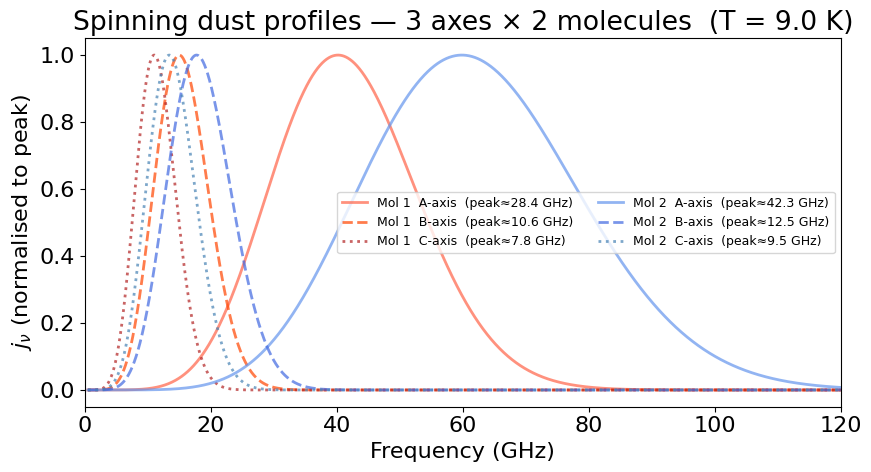

In [5]:
def spinning_profile(nu_GHz, B_cm, T_K):
    """
    Spinning dust emissivity shape for a single rotational axis.

    Parameters
    ----------
    nu_GHz : array_like
        Frequencies at which to evaluate the profile [GHz].
    B_cm : float
        Rotational constant for this axis [cm^-1].
    T_K : float
        Kinetic temperature [K].

    Returns
    -------
    array
        j_nu values (unnormalised Draine & Lazarian shape).
    """
    E_B_J_loc = B_cm * 1e2 * h * c_0
    B_kT_loc  = E_B_J_loc / (k_B * T_K)
    J_arr     = np.arange(0, 1001)
    P_arr     = P_J(J_arr, B_kT=B_kT_loc)
    S_arr     = spin_J_GHz(J_arr, B=B_cm)
    nu2_loc   = np.sum(P_arr * S_arr**2) / np.sum(P_arr)   # ⟨ν²⟩ for this axis
    return jansky_nu(nu_GHz, nu2_loc)


# ─── Molecule definitions ────────────────────────────────────────────────────
# Replace with literature values (e.g. from CDMS or JPL spectral catalogue).
# Molecule 1: small PAH, roughly naphthalene-sized (~10 C atoms)
A1, B1_mol, C1 = 0.036, 0.0050, 0.0027   # cm^-1, 15672
# Molecule 2: larger PAH, roughly coronene-sized (~24 C atoms)
A2, B2_mol, C2 = 0.080, 0.007, 0.004   # cm^-1, 15272

T_both = 9.0   # K — same temperature for both molecules

# Dictionary: label → (B_axis, T)
mol_params = {
    'Mol 1  A-axis': (A1,     T_both),
    'Mol 1  B-axis': (B1_mol, T_both),
    'Mol 1  C-axis': (C1,     T_both),
    'Mol 2  A-axis': (A2,     T_both),
    'Mol 2  B-axis': (B2_mol, T_both),
    'Mol 2  C-axis': (C2,     T_both),
}

nu_plot = np.linspace(0.5, 120, 2000)   # GHz, dense grid for smooth curves

# Build normalised profiles (peak = 1) for visual comparison.
# The absolute amplitude is a free parameter absorbed into the fit.
profiles_norm = {}
for label, (B_ax, T_ax) in mol_params.items():
    p = spinning_profile(nu_plot, B_ax, T_ax)
    profiles_norm[label] = p / np.max(p)

# ─── Plot ────────────────────────────────────────────────────────────────────
colors_6   = ['tomato', 'orangered', 'firebrick',
              'cornflowerblue', 'royalblue', 'steelblue']
linestyles = ['-', '--', ':'] * 2

fig, ax = plt.subplots(figsize=(9, 5))
for (label, profile), color, ls in zip(profiles_norm.items(), colors_6, linestyles):
    B_ax = mol_params[label][0]
    nu2_ax = np.sum(P_J(np.arange(1001), B_kT=B_ax*1e2*h*c_0/(k_B*T_both)) *
                    spin_J_GHz(np.arange(1001), B=B_ax)**2) / \
             np.sum(P_J(np.arange(1001), B_kT=B_ax*1e2*h*c_0/(k_B*T_both)))
    ax.plot(nu_plot, profile, label=f"{label}  (peak≈{nu2_ax**0.5:.1f} GHz)",
            color=color, linestyle=ls, lw=2, alpha = 0.7)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"$j_\nu$ (normalised to peak)")
ax.set_title(f"Spinning dust profiles — 3 axes × 2 molecules  (T = {T_both} K)")
ax.set_xlim(0, 120)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

Profile                  Fitted
--------------------------------
Mol 1  A-axis            27.934
Mol 1  B-axis             0.000
Mol 1  C-axis             0.000
Mol 2  A-axis             0.000
Mol 2  B-axis            27.329
Mol 2  C-axis             0.000

reduced chi² = 0.977  (chi²=21.490, dof=22)


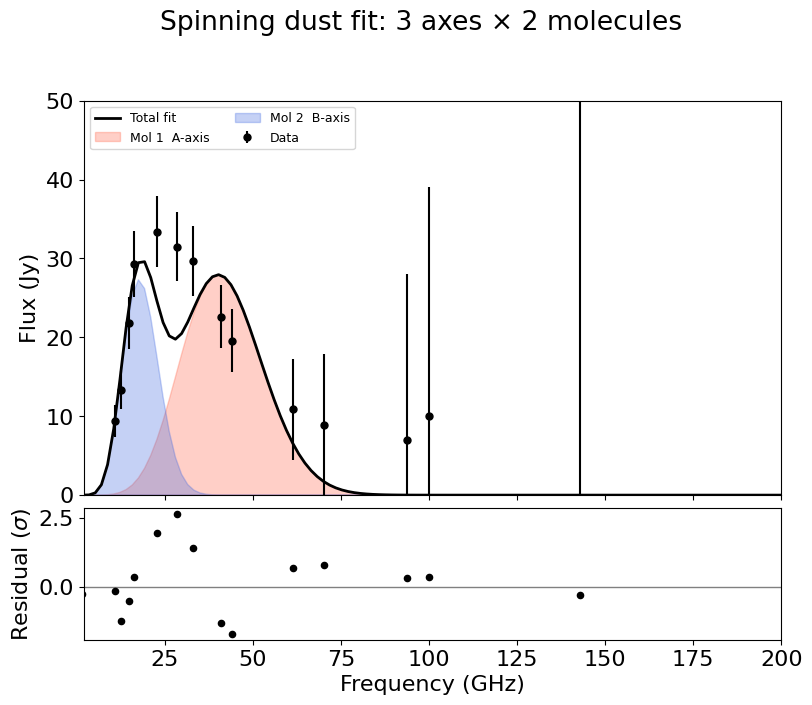

In [6]:
# ─── Fit six-profile superposition to data ───────────────────────────────────
#
# Model:  F(ν) = Σ_{i=1}^{6} a_i × P_i(ν)
#
# where P_i is the normalised spinning dust profile for axis/molecule i
# (peak = 1 on the nu_plot grid) and a_i ≥ 0 are free amplitudes.
# Non-negative least squares (NNLS) is used: physically, column densities
# and dipole moments are strictly non-negative.

# ── Provide your data here ──────────────────────────────────────────────────
# nu_data  [GHz]  — observed frequency channels
# flux_data [Jy]  — observed specific intensity (or antenna temperature, etc.)
# flux_err  [Jy]  — 1-sigma uncertainties (used for chi^2 weighting)
#
# Synthetic data for demonstration; replace the three lines below:
# rng       = np.random.default_rng(42)
# nu_data   = np.array([5, 8, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100], dtype=float)
# flux_err  = 0.05 * np.ones(len(nu_data))

# true_amps = np.array([1.5, 0.8, 1.2, 2.0, 0.5, 0.3])   # Jy


# def build_model_matrix(nu_GHz):
#     """Build the (N_freq × 6) design matrix.  Column i = profile i at nu_GHz."""
#     M = np.zeros((len(nu_GHz), len(mol_params)))
#     for i, (label, (B_ax, T_ax)) in enumerate(mol_params.items()):
#         p      = spinning_profile(nu_GHz, B_ax, T_ax)
#         p_norm = p / np.max(spinning_profile(nu_plot, B_ax, T_ax))   # same normalisation as plots
#         M[:, i] = p_norm
#     return M


# M_data     = build_model_matrix(nu_data)
# flux_synth = M_data @ true_amps + flux_err * rng.standard_normal(len(nu_data))
# flux_data  = flux_synth   # ← replace with real observations


nu_data = np.array([
    0.408, 0.82, 1.42, 10.9, 12.7, 14.7, 16.3, 22.8, 28.5, 33.0,
    40.9, 44.1, 61.3, 70.3, 93.8, 100, 143, 217, 353, 545, 857,
    1250, 2143, 2997
])  # GHz

# flux = np.array([
#     9.7, 9.4, 8.0, 16.1, 20.0, 28.4, 35.8, 39.8, 38.1, 36.7,
#     30.8, 28.5, 27.4, 32.2, 63.0, 78, 202, 1050, 3860, 15300, 48700,
#     93000, 117000, 53600
# ])  # Jy

# flux_err = np.array([
#     3.3, 4.7, 1.7, 1.8, 2.2, 3.1, 4.0, 4.2, 4.0, 3.9,
#     3.3, 3.2, 3.4, 3.9, 7.8, 15, 22, 130, 470, 2100, 6100,
#     13000, 15000, 6700
# ])  # Jy

flux_data = np.array([
    0.2, 0.5, -0.5, 9.4, 13.3, 21.8, 29.3, 33.4, 31.5, 29.7,
    22.6, 19.6, 10.9, 8.9, 7, 10, -25, 120, -600, -800, -1000,
    -2400, 7000, -2000
])  # Jy

flux_err = np.array([
    3.4, 4.8, 1.8, 2.0, 2.4, 3.3, 4.2, 4.5, 4.4, 4.4,
    4.0, 4.0, 6.4, 9.0, 21, 29, 80, 320, 1400, 4900, 14000,
    28000, 35000, 20000
])  # Jy

def build_model_matrix(nu_GHz):
    M = np.zeros((len(nu_GHz), len(mol_params)))
    for i, (label, (B_ax, T_ax)) in enumerate(mol_params.items()):
        p      = spinning_profile(nu_GHz, B_ax, T_ax)
        p_norm = p / np.max(spinning_profile(nu_plot, B_ax, T_ax))
        M[:, i] = p_norm
    return M

M_data = build_model_matrix(nu_data)

# ── NNLS fit ────────────────────────────────────────────────────────────────
# Weight data points by 1/sigma before passing to NNLS so that the solver
# minimises the chi^2: Σ [(F_obs - F_model) / σ]²
M_w    = M_data   / flux_err[:, None]
flux_w = flux_data / flux_err

fit_amps, _ = nnls(M_w, flux_w)

# ── Print results ────────────────────────────────────────────────────────────
print(f"{'Profile':<22} {'Fitted':>8}")
print("-" * 32)
for label, amp in zip(mol_params.keys(), fit_amps):
    print(f"{label:<22} {amp:8.3f}")
    
flux_model_at_data = M_data @ fit_amps
chi2 = np.sum(((flux_data - flux_model_at_data) / flux_err)**2)
dof  = len(nu_data) - np.sum(fit_amps > 0)
print(f"\nreduced chi² = {chi2/dof:.3f}  (chi²={chi2:.3f}, dof={dof})")

# ── Plot: data + total fit + individual contributions ───────────────────────
nu_fine    = np.linspace(0, 3500, 2000)
M_fine     = build_model_matrix(nu_fine)
flux_model = M_fine @ fit_amps

fig, (ax_top, ax_res) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

ax_top.errorbar(nu_data, flux_data, yerr=flux_err, fmt='o', color='k',
                label='Data', zorder=5, ms=5)
ax_top.plot(nu_fine, flux_model, 'k-', lw=2, label='Total fit')

for (label, (B_ax, T_ax)), color, ls, amp in zip(
        mol_params.items(), colors_6, linestyles, fit_amps):
    if amp < 1e-6:
        continue
    p_fine      = spinning_profile(nu_fine, B_ax, T_ax)
    p_fine_norm = p_fine / np.max(spinning_profile(nu_plot, B_ax, T_ax))
    ax_top.fill_between(nu_fine, amp * p_fine_norm, alpha=0.3,
                        color=color, label=label)

ax_top.set_ylabel("Flux (Jy)")
ax_top.legend(fontsize=9, ncol=2)
ax_top.set_xlim(2, 200)
ax_top.set_ylim(0, 50)

ax_res.scatter(nu_data,
               (flux_data - flux_model_at_data) / flux_err,
               color='k', s=20, zorder=5)
ax_res.axhline(0, color='gray', lw=1)
ax_res.set_xlabel("Frequency (GHz)")
ax_res.set_ylabel(r"Residual ($\sigma$)")

plt.suptitle("Spinning dust fit: 3 axes × 2 molecules", y=1.01)
# plt.tight_layout()
plt.show()

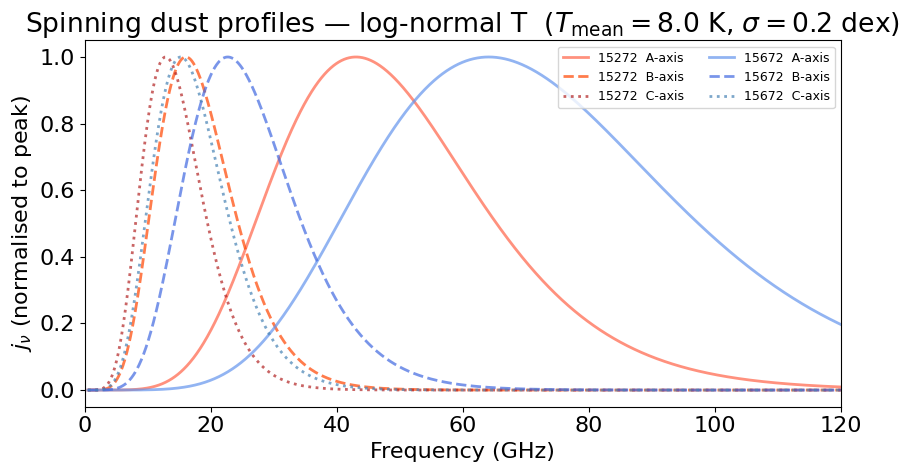

In [7]:
def spinning_profile_lognorm(nu_GHz, B_cm, T_mean_K, T_sigma_dex, N_T=30):
    """
    Spinning dust emissivity averaged over a log-normal temperature distribution.

    Parameters
    ----------
    nu_GHz    : array_like  — frequencies [GHz]
    B_cm      : float       — rotational constant [cm^-1]
    T_mean_K  : float       — geometric mean temperature [K]
    T_sigma_dex : float     — width of log-normal in dex (i.e. sigma of log10 T)
    N_T       : int         — number of quadrature points over T

    Returns
    -------
    array — j_nu averaged over T distribution (unnormalised)
    """
    # Gauss-Hermite quadrature in log10(T) space:
    # log10(T) ~ Normal(log10(T_mean), T_sigma_dex)
    # Integral becomes: ∫ f(T) * p(T) dT  ≈  Σ_i w_i * f(T_i)
    gh_nodes, gh_weights = np.polynomial.hermite.hermgauss(N_T)

    # Map nodes to physical temperatures:
    # x = (log10(T) - log10(T_mean)) / (sqrt(2) * T_sigma_dex)
    # => log10(T) = sqrt(2) * T_sigma_dex * x + log10(T_mean)
    log10_T_mean = np.log10(T_mean_K)
    log10_T_nodes = np.sqrt(2) * T_sigma_dex * gh_nodes + log10_T_mean
    T_nodes = 10**log10_T_nodes  # physical temperatures at quadrature points

    # Gauss-Hermite weights already include the 1/sqrt(pi) normalisation
    profile_avg = np.zeros(len(np.atleast_1d(nu_GHz)))
    for T_i, w_i in zip(T_nodes, gh_weights):
        profile_avg += w_i * spinning_profile(nu_GHz, B_cm, T_i)
    profile_avg /= np.sqrt(np.pi)  # normalise the Gauss-Hermite sum

    return profile_avg


# ─── Molecule definitions ─────────────────────────────────────────────────────
A1, B1_mol, C1 = 0.036, 0.0050, 0.0032   # cm^-1, 15272
A2, B2_mol, C2 = 0.080, 0.01,  0.0045    # cm^-1, 15672

T_mean  = 8.0   # K  — geometric mean of log-normal
T_sigma = 0.2   # dex — width; 0 recovers the single-T limit, ~0.3 is physically motivated

# Dictionary: label → (B_axis, T_mean, T_sigma)
mol_params = {
    '15272  A-axis': (A1,     T_mean, T_sigma),
    '15272  B-axis': (B1_mol, T_mean, T_sigma),
    '15272  C-axis': (C1,     T_mean, T_sigma),
    '15672  A-axis': (A2,     T_mean, T_sigma),
    '15672  B-axis': (B2_mol, T_mean, T_sigma),
    '15672  C-axis': (C2,     T_mean, T_sigma),
}

nu_plot = np.linspace(0.5, 120, 2000)

# ─── Build normalised profiles ────────────────────────────────────────────────
profiles_norm = {}
for label, (B_ax, T_ax, sig_ax) in mol_params.items():
    p = spinning_profile_lognorm(nu_plot, B_ax, T_ax, sig_ax)
    profiles_norm[label] = p / np.max(p)

# ─── Update build_model_matrix ───────────────────────────────────────────────
def build_model_matrix(nu_GHz):
    M = np.zeros((len(nu_GHz), len(mol_params)))
    for i, (label, (B_ax, T_ax, sig_ax)) in enumerate(mol_params.items()):
        p      = spinning_profile_lognorm(nu_GHz, B_ax, T_ax, sig_ax)
        p_norm = p / np.max(spinning_profile_lognorm(nu_plot, B_ax, T_ax, sig_ax))
        M[:, i] = p_norm
    return M

# ─── Plot ─────────────────────────────────────────────────────────────────────
colors_6   = ['tomato', 'orangered', 'firebrick',
              'cornflowerblue', 'royalblue', 'steelblue']
linestyles = ['-', '--', ':'] * 2

fig, ax = plt.subplots(figsize=(9, 5))
for (label, profile), color, ls in zip(profiles_norm.items(), colors_6, linestyles):
    ax.plot(nu_plot, profile, label=label, color=color, linestyle=ls, lw=2, alpha=0.7)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"$j_\nu$ (normalised to peak)")
ax.set_title(f"Spinning dust profiles — log-normal T  "
             f"($T_{{\\mathrm{{mean}}}}={T_mean}$ K, $\\sigma={T_sigma}$ dex)")
ax.set_xlim(0, 120)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

Profile                  Fitted
--------------------------------
15272  A-axis            14.191
15272  B-axis             5.824
15272  C-axis             0.000
15672  A-axis             2.681
15672  B-axis            27.251
15672  C-axis             0.000

reduced chi² = 0.109  (chi²=2.186, dof=20)


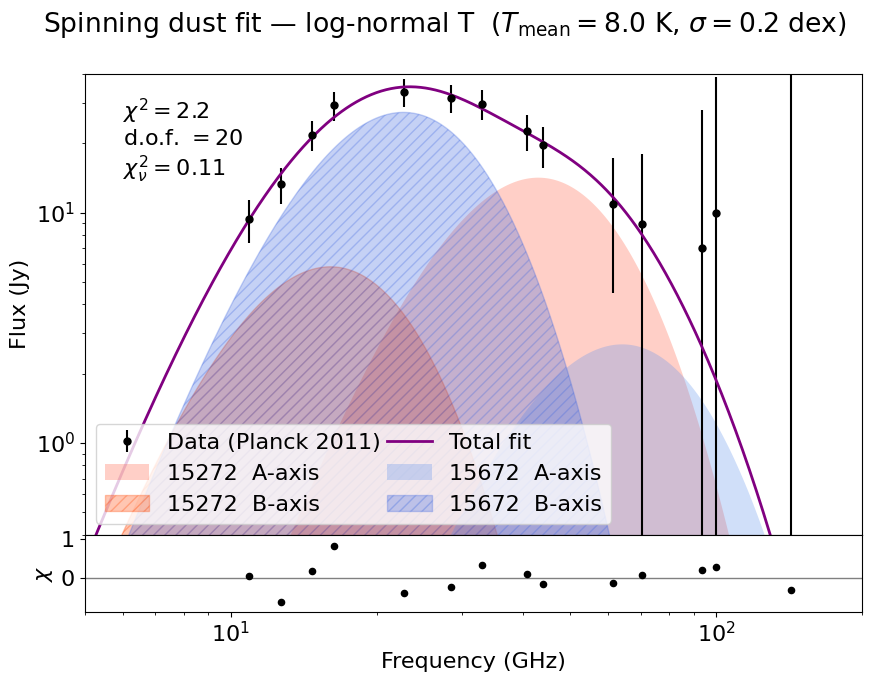

In [8]:
# ── NNLS fit ─────────────────────────────────────────────────────────────────

M_data = build_model_matrix(nu_data)  # already uses spinning_profile_lognorm

M_w    = M_data    / flux_err[:, None]
flux_w = flux_data / flux_err

fit_amps, _ = nnls(M_w, flux_w)

# ── Print results ─────────────────────────────────────────────────────────────
print(f"{'Profile':<22} {'Fitted':>8}")
print("-" * 32)
for label, amp in zip(mol_params.keys(), fit_amps):
    print(f"{label:<22} {amp:8.3f}")

flux_model_at_data = M_data @ fit_amps
chi2 = np.sum(((flux_data - flux_model_at_data) / flux_err)**2)
dof  = len(nu_data) - np.sum(fit_amps > 0)
print(f"\nreduced chi² = {chi2/dof:.3f}  (chi²={chi2:.3f}, dof={dof})")

# ── Plot ──────────────────────────────────────────────────────────────────────
nu_fine    = np.logspace(np.log10(0.3), np.log10(3500), 2000)
M_fine     = build_model_matrix(nu_fine)
flux_model = M_fine @ fit_amps

fig, (ax_top, ax_res) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={'height_ratios': [6, 1], 'hspace': 0.00}
)

ax_top.errorbar(nu_data, flux_data, yerr=flux_err, fmt='o', color='k',
                label='Data (Planck 2011)', ms=5)
ax_top.plot(nu_fine, flux_model, c = 'purple', lw=2, label='Total fit')

for (label, (B_ax, T_ax, sig_ax)), color, ls, amp in zip(
        mol_params.items(), colors_6, linestyles, fit_amps):
    if amp < 1e-6:
        continue
    p_fine      = spinning_profile_lognorm(nu_fine, B_ax, T_ax, sig_ax)
    p_fine_norm = p_fine / np.max(spinning_profile_lognorm(nu_plot, B_ax, T_ax, sig_ax))
    is_b_axis   = 'B-axis' in label
    ax_top.fill_between(nu_fine, amp * p_fine_norm, alpha=0.3,
                        color=color, label=label,
                        hatch='///' if is_b_axis else None,
                        edgecolor=color if is_b_axis else None)

ax_top.set_ylabel("Flux (Jy)")

handles, labels = ax_top.get_legend_handles_labels()

# Current order: [Data, Total fit, comp1, comp2, ...]
# Target:        [Data, comp1, comp2, Total fit, ...]
order = [5, 1, 2, 0, 3, 4]
handles = [handles[i] for i in order]
labels  = [labels[i]  for i in order]

ax_top.legend(handles, labels, fontsize=16, ncol=2, loc='lower left', columnspacing=0.3)

ax_top.set_xscale('log')
ax_top.set_yscale('log')
ax_top.set_xlim(5, 200)
ax_top.set_ylim(0.4, 40)

ax_top.text(0.05, 0.95,
            rf"$\chi^2 = {chi2:.1f}$" + "\n"
            rf"d.o.f. $= {dof}$" + "\n"
            rf"$\chi^2_\nu = {chi2/dof:.2f}$",
            transform=ax_top.transAxes,
            fontsize=16, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0))

ax_res.scatter(nu_data,
               (flux_data - flux_model_at_data) / flux_err,
               color='k', s=20, zorder=5)

ax_res.axhline(0, color='gray', lw=1)
ax_res.set_xlabel("Frequency (GHz)")
ax_res.set_ylabel(r"$\chi$")
f = 1.25
ax_res.set_ylim(ax_res.get_ylim()[0]*f, ax_res.get_ylim()[1]*f)

plt.suptitle(
    f"Spinning dust fit — log-normal T  "
    f"($T_{{\\mathrm{{mean}}}}={T_mean}$ K, $\\sigma={T_sigma}$ dex)",
    y=0.98, x = 0.51
)
plt.tight_layout()
plt.show()

Profile                 Perseus  rho-Ophiuchi
------------------------------------------
15272  A-axis            14.191    16.959
15272  B-axis             5.824     0.000
15272  C-axis             0.000     0.000
15672  A-axis             2.681     0.027
15672  B-axis            27.251    21.055
15672  C-axis             0.000     0.000


/tmp/ipykernel_1595827/1248312340.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


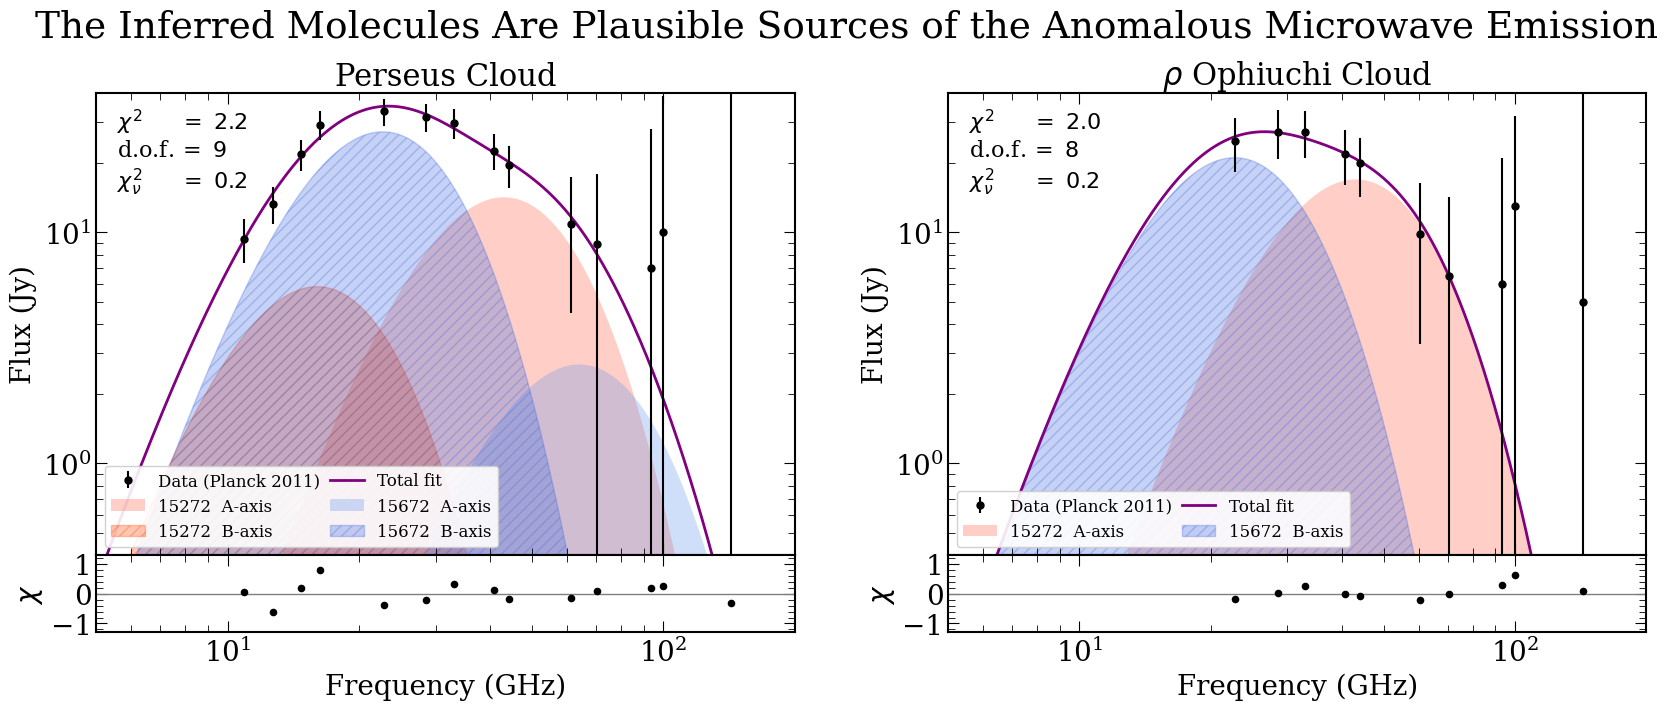

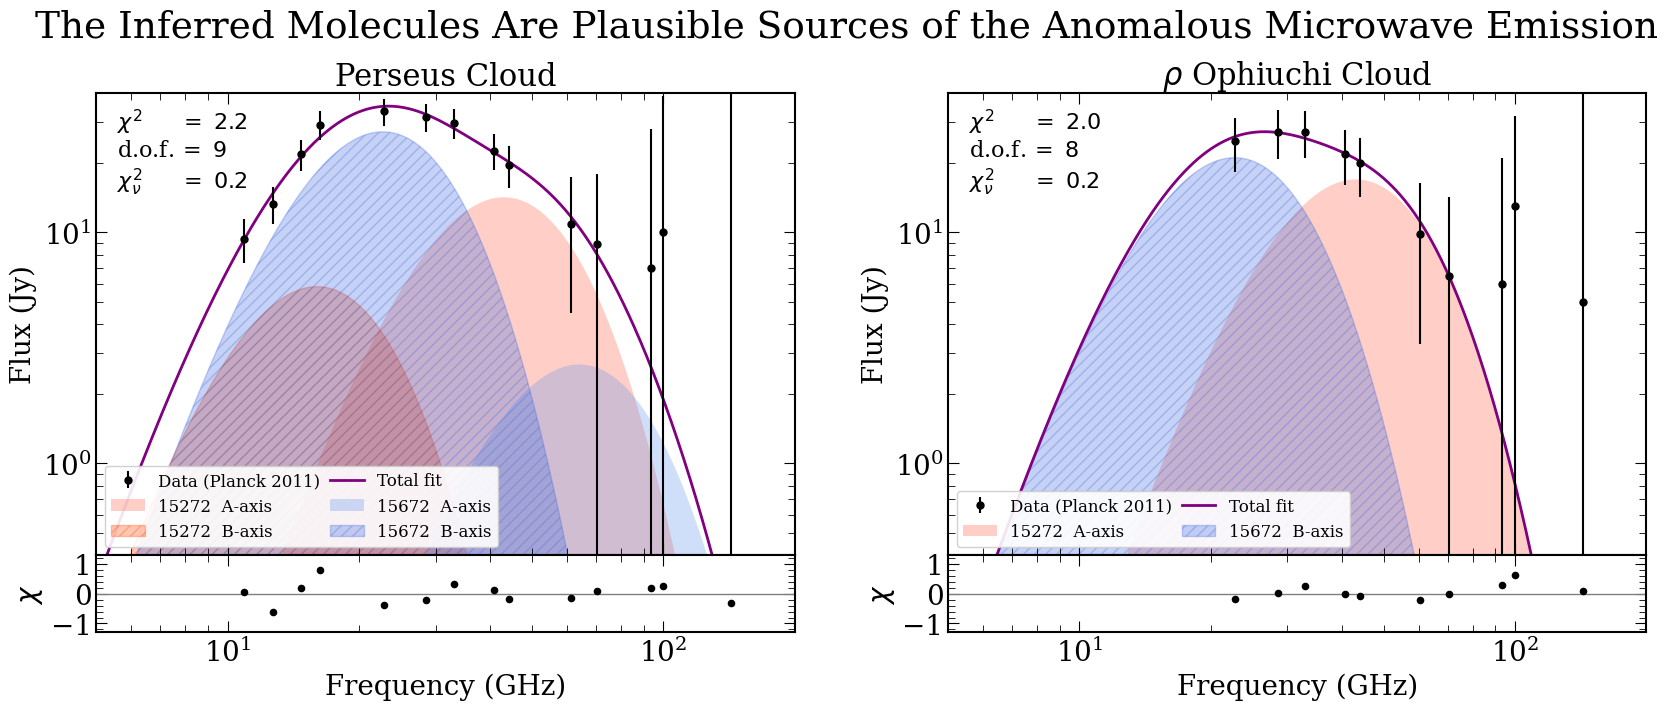

In [13]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=8, pad=4)
plt.rc('xtick.minor', size=5)
plt.rc('ytick.major', size=8)
plt.rc('ytick.minor', size=5)
plt.rc('legend', fontsize=16)

nu_data2 = np.array([
    0.4, 1.4, 2.3, 22.7, 28.5, 33.0, 40.7, 44.1, 60.6, 70.3,
    93.4, 100, 143, 217, 353, 545, 857, 1249, 2141, 2997
])  # GHz

flux_data2 = np.array([
    -7, -1.0, 1.2, 24.8, 27.3, 27.2, 21.9, 19.9, 9.8, 6.5,
    6, 13, 5, 130, -180, 400, 500, -5000, 20000, -9000
])  # Jy

flux2_err = np.array([
    11, 8.3, 8.3, 6.6, 6.6, 6.3, 5.8, 5.7, 6.5, 7.8,
    15, 19, 49, 200, 780, 3200, 10000, 25000, 41000, 32000
])  # Jy


# ── Fit both datasets ─────────────────────────────────────────────────────────
M_data = build_model_matrix(nu_data)

# Dataset 1
M_w1    = M_data / flux_err[:, None]
flux_w1 = flux_data / flux_err
fit_amps1, _ = nnls(M_w1, flux_w1)
flux_model1 = M_fine @ fit_amps1
flux_model_at_data1 = M_data @ fit_amps1
chi2_1 = np.sum(((flux_data  - flux_model_at_data1) / flux_err)**2)
mask = np.logical_and(nu_data>5, nu_data<200)
dof_1  = sum( np.logical_and(flux_data>0, mask) ) - sum(fit_amps1>0.1)

M_data2 = build_model_matrix(nu_data2)
# Dataset 2
M_w2    = M_data2 / flux2_err[:, None]
flux_w2 = flux_data2 / flux2_err
fit_amps2, _ = nnls(M_w2, flux_w2)
flux_model2 = M_fine @ fit_amps2
flux_model_at_data2 = M_data2 @ fit_amps2
chi2_2 = np.sum(((flux_data2 - flux_model_at_data2) / flux2_err)**2)
# dof_2  = len(nu_data2) - len(fit_amps2)
mask = np.logical_and(nu_data2>5, nu_data2<200)
dof_2 = sum( np.logical_and(flux_data2>0, mask) ) - sum(fit_amps2>0.1)

print(f"{'Profile':<22} {'Perseus':>8}  {'rho-Ophiuchi':>8}")
print("-" * 42)
for label, a1, a2 in zip(mol_params.keys(), fit_amps1, fit_amps2):
    print(f"{label:<22} {a1:8.3f}  {a2:8.3f}")

# ── Fine grid for smooth model curves ────────────────────────────────────────
nu_fine    = np.logspace(np.log10(0.3), np.log10(3500), 2000)
M_fine2 = build_model_matrix(nu_data2)  # for residuals on nu_data2 grid
# Note: smooth model curve still uses nu_fine
flux_model2 = M_fine @ fit_amps2  # M_fine is on nu_fine, correct for plotting
flux_model_at_data2 = M_data2 @ fit_amps2  # M_data2 is on nu_data2, correct for residuals

# ── Figure: 2 columns × 2 rows ───────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2, figsize=(20, 7), sharex=True,
    gridspec_kw={'height_ratios': [6, 1], 'hspace': 0.00, 'wspace': 0.22}
)
(ax1, ax2), (ax_res1, ax_res2) = axes

# https://www.aanda.org/articles/aa/pdf/2011/12/aa16470-11.pdf
datasets = [
    (ax1, ax_res1, nu_data,  flux_data,  flux_err,  fit_amps1, M_fine,  flux_model1, flux_model_at_data1, chi2_1, dof_1, 'Perseus Cloud'),
    (ax2, ax_res2, nu_data2, flux_data2, flux2_err, fit_amps2, M_fine2, flux_model2, flux_model_at_data2, chi2_2, dof_2, r'$\rho$ Ophiuchi Cloud'),
]

for ax_top, ax_res, nu, fdata, ferr, fit_amps, _, flux_model, flux_model_at_data, chi2, dof, title in datasets:

    ax_top.errorbar(nu, fdata, yerr=ferr, fmt='o', color='k',
                    label='Data (Planck 2011)', ms=5, zorder=5)
    ax_top.plot(nu_fine, flux_model, c='purple', lw=2, label='Total fit')

    for (label, (B_ax, T_ax, sig_ax)), color, ls, amp in zip(
            mol_params.items(), colors_6, linestyles, fit_amps):
        if amp < 1e-1:
            continue
        p_fine      = spinning_profile_lognorm(nu_fine, B_ax, T_ax, sig_ax)
        p_fine_norm = p_fine / np.max(spinning_profile_lognorm(nu_plot, B_ax, T_ax, sig_ax))
        is_b_axis   = 'B-axis' in label
        ax_top.fill_between(nu_fine, amp * p_fine_norm, alpha=0.3,
                            color=color, label=label,
                            hatch='///' if is_b_axis else None,
                            edgecolor=color if is_b_axis else None)

    ax_top.set_ylabel("Flux (Jy)")
    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.set_xlim(5, 200)
    ax_top.set_ylim(0.4, 40)
    ax_top.set_title(title)

    handles, lbls = ax_top.get_legend_handles_labels()
    if len(handles) == 4:
        order   = [3,1,0,2]
    if len(handles) == 5:
        order   = [4, 2, 3, 0, 1]
    if len(handles) == 6:
        order   = [5, 1, 2, 0, 3, 4]
    handles = [handles[i] for i in order]
    lbls    = [lbls[i]    for i in order]
    ax_top.legend(handles, lbls, fontsize=12, ncol=2, loc='lower left', columnspacing=0.6, framealpha = 0.9)

    ax_top.text(0.03, 0.97,
                rf"$\chi^2~~~~~=~{chi2:.1f}$" + "\n"
                rf"d.o.f.$\,=~{dof}$" + "\n"
                rf"$\chi^2_\nu~~~~~=~{chi2/dof:.1f}$",
                transform=ax_top.transAxes,
                fontsize=16, ha='left', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0))

    ax_res.scatter(nu, (fdata - flux_model_at_data) / ferr,
                   color='k', s=20, zorder=5)
    ax_res.axhline(0, color='gray', lw=1)
    ax_res.set_xlabel("Frequency (GHz)")
    ax_res.set_ylabel(r"$\chi$")
    f = 1.3
    m = np.max([np.max(np.abs(ax_res.get_ylim())), 1])
    ax_res.set_ylim(-m*f, m*f)

# plt.suptitle(
#     f"Spinning dust fit — log-normal T  "
#     f"($T_{{\\mathrm{{mean}}}}={T_mean}$ K, $\\sigma={T_sigma}$ dex)",
#     y=0.98
# )

plt.suptitle( "The Inferred Molecules Are Plausible Sources of the Anomalous Microwave Emission", y = 1.0, fontsize = 27)

plt.tight_layout()
plt.savefig(osp.expanduser('~/DIB/figs/AME_plot.png'), bbox_inches = 'tight', dpi = 200)

plt.show()

Profile                 Perseus  rho-Ophiuchi
------------------------------------------
15272  A-axis            14.191    16.959
15272  B-axis             5.824     0.000
15272  C-axis             0.000     0.000
15672  A-axis             2.681     0.027
15672  B-axis            27.251    21.055
15672  C-axis             0.000     0.000


/tmp/ipykernel_1595827/1387358139.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


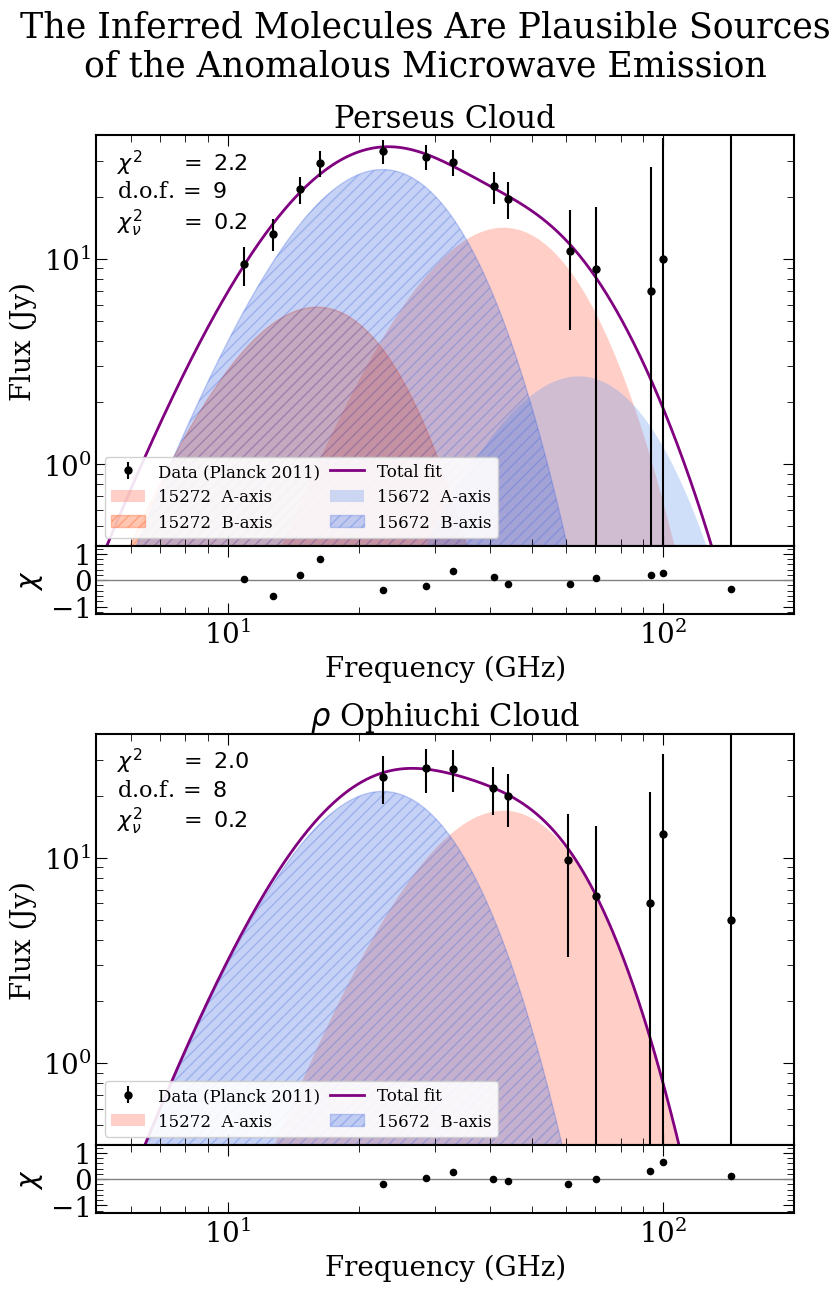

In [27]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=8, pad=4)
plt.rc('xtick.minor', size=5)
plt.rc('ytick.major', size=8)
plt.rc('ytick.minor', size=5)
plt.rc('legend', fontsize=16)

nu_data2 = np.array([
    0.4, 1.4, 2.3, 22.7, 28.5, 33.0, 40.7, 44.1, 60.6, 70.3,
    93.4, 100, 143, 217, 353, 545, 857, 1249, 2141, 2997
])  # GHz

flux_data2 = np.array([
    -7, -1.0, 1.2, 24.8, 27.3, 27.2, 21.9, 19.9, 9.8, 6.5,
    6, 13, 5, 130, -180, 400, 500, -5000, 20000, -9000
])  # Jy

flux2_err = np.array([
    11, 8.3, 8.3, 6.6, 6.6, 6.3, 5.8, 5.7, 6.5, 7.8,
    15, 19, 49, 200, 780, 3200, 10000, 25000, 41000, 32000
])  # Jy


# ── Fit both datasets ─────────────────────────────────────────────────────────
M_data = build_model_matrix(nu_data)

# Dataset 1
M_w1    = M_data / flux_err[:, None]
flux_w1 = flux_data / flux_err
fit_amps1, _ = nnls(M_w1, flux_w1)
flux_model1 = M_fine @ fit_amps1
flux_model_at_data1 = M_data @ fit_amps1
chi2_1 = np.sum(((flux_data  - flux_model_at_data1) / flux_err)**2)
mask = np.logical_and(nu_data>5, nu_data<200)
dof_1  = sum( np.logical_and(flux_data>0, mask) ) - sum(fit_amps1>0.1)

M_data2 = build_model_matrix(nu_data2)
# Dataset 2
M_w2    = M_data2 / flux2_err[:, None]
flux_w2 = flux_data2 / flux2_err
fit_amps2, _ = nnls(M_w2, flux_w2)
flux_model2 = M_fine @ fit_amps2
flux_model_at_data2 = M_data2 @ fit_amps2
chi2_2 = np.sum(((flux_data2 - flux_model_at_data2) / flux2_err)**2)
# dof_2  = len(nu_data2) - len(fit_amps2)
mask = np.logical_and(nu_data2>5, nu_data2<200)
dof_2 = sum( np.logical_and(flux_data2>0, mask) ) - sum(fit_amps2>0.1)

print(f"{'Profile':<22} {'Perseus':>8}  {'rho-Ophiuchi':>8}")
print("-" * 42)
for label, a1, a2 in zip(mol_params.keys(), fit_amps1, fit_amps2):
    print(f"{label:<22} {a1:8.3f}  {a2:8.3f}")

# ── Fine grid for smooth model curves ────────────────────────────────────────
nu_fine    = np.logspace(np.log10(0.3), np.log10(3500), 2000)
M_fine2 = build_model_matrix(nu_data2)  # for residuals on nu_data2 grid
# Note: smooth model curve still uses nu_fine
flux_model2 = M_fine @ fit_amps2  # M_fine is on nu_fine, correct for plotting
flux_model_at_data2 = M_data2 @ fit_amps2  # M_data2 is on nu_data2, correct for residuals

# ── Figure: 2 columns × 2 rows ───────────────────────────────────────────────
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(9, 14))
gs_outer = GridSpec(2, 1, hspace=0.25, figure=fig)

gs1 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[0], hspace=0, height_ratios=[6, 1])
gs2 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[1], hspace=0, height_ratios=[6, 1])

ax1     = fig.add_subplot(gs1[0])
ax_res1 = fig.add_subplot(gs1[1], sharex=ax1)
ax2     = fig.add_subplot(gs2[0], sharex=ax1)
ax_res2 = fig.add_subplot(gs2[1], sharex=ax1)

# https://www.aanda.org/articles/aa/pdf/2011/12/aa16470-11.pdf
datasets = [
    (ax1, ax_res1, nu_data,  flux_data,  flux_err,  fit_amps1, M_fine,  flux_model1, flux_model_at_data1, chi2_1, dof_1, 'Perseus Cloud'),
    (ax2, ax_res2, nu_data2, flux_data2, flux2_err, fit_amps2, M_fine2, flux_model2, flux_model_at_data2, chi2_2, dof_2, r'$\rho$ Ophiuchi Cloud'),
]

for ax_top, ax_res, nu, fdata, ferr, fit_amps, _, flux_model, flux_model_at_data, chi2, dof, title in datasets:

    ax_top.errorbar(nu, fdata, yerr=ferr, fmt='o', color='k',
                    label='Data (Planck 2011)', ms=5, zorder=5)
    ax_top.plot(nu_fine, flux_model, c='purple', lw=2, label='Total fit')

    for (label, (B_ax, T_ax, sig_ax)), color, ls, amp in zip(
            mol_params.items(), colors_6, linestyles, fit_amps):
        if amp < 1e-1:
            continue
        p_fine      = spinning_profile_lognorm(nu_fine, B_ax, T_ax, sig_ax)
        p_fine_norm = p_fine / np.max(spinning_profile_lognorm(nu_plot, B_ax, T_ax, sig_ax))
        is_b_axis   = 'B-axis' in label
        ax_top.fill_between(nu_fine, amp * p_fine_norm, alpha=0.3,
                            color=color, label=label,
                            hatch='///' if is_b_axis else None,
                            edgecolor=color if is_b_axis else None)

    ax_top.set_ylabel("Flux (Jy)")
    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.set_xlim(5, 200)
    ax_top.set_ylim(0.4, 40)
    ax_top.set_title(title)

    handles, lbls = ax_top.get_legend_handles_labels()
    if len(handles) == 4:
        order   = [3,1,0,2]
    if len(handles) == 5:
        order   = [4, 2, 3, 0, 1]
    if len(handles) == 6:
        order   = [5, 1, 2, 0, 3, 4]
    handles = [handles[i] for i in order]
    lbls    = [lbls[i]    for i in order]
    ax_top.legend(handles, lbls, fontsize=12, ncol=2, loc='lower left', columnspacing=0.6, framealpha = 0.9)

    ax_top.text(0.03, 0.97,
                rf"$\chi^2~~~~~=~{chi2:.1f}$" + "\n"
                rf"d.o.f.$\,=~{dof}$" + "\n"
                rf"$\chi^2_\nu~~~~~=~{chi2/dof:.1f}$",
                transform=ax_top.transAxes,
                fontsize=16, ha='left', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0))

    ax_res.scatter(nu, (fdata - flux_model_at_data) / ferr,
                   color='k', s=20, zorder=5)
    ax_res.axhline(0, color='gray', lw=1)
    ax_res.set_xlabel("Frequency (GHz)")
    ax_res.set_ylabel(r"$\chi$")
    f = 1.3
    m = np.max([np.max(np.abs(ax_res.get_ylim())), 1])
    ax_res.set_ylim(-m*f, m*f)

# plt.suptitle(
#     f"Spinning dust fit — log-normal T  "
#     f"($T_{{\\mathrm{{mean}}}}={T_mean}$ K, $\\sigma={T_sigma}$ dex)",
#     y=0.98
# )

plt.suptitle( "The Inferred Molecules Are Plausible Sources\nof the Anomalous Microwave Emission", y = 0.97, x = 0.49, fontsize = 25)

plt.tight_layout()
plt.savefig(osp.expanduser('~/DIB/figs/AME_plot_vertical.png'), bbox_inches = 'tight', dpi = 200)

plt.show()

Median:       8.00
16th pctile:  6.56
84th pctile:  9.76


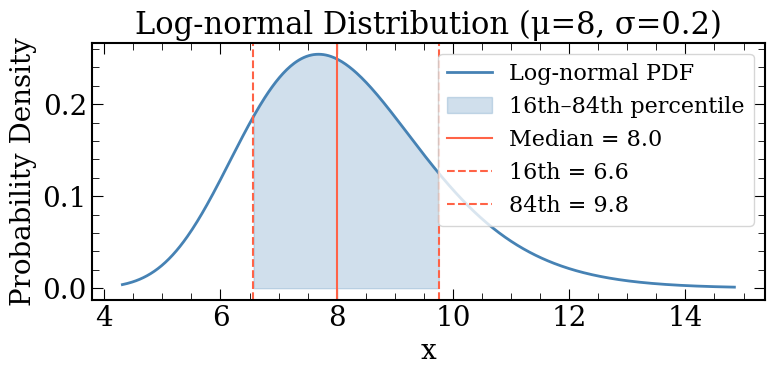

In [10]:
from scipy.stats import lognorm

mu, sig = 8, 0.2

# Scipy lognorm: s=sigma, scale=exp(mu)
dist = lognorm(s=sig, scale=mu)
x = np.linspace(dist.ppf(0.001), dist.ppf(0.999), 500)

# Stats
median = dist.median()
p16 = dist.ppf(0.16)
p84 = dist.ppf(0.84)
print(f"Median:       {median:.2f}")
print(f"16th pctile:  {p16:.2f}")
print(f"84th pctile:  {p84:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, dist.pdf(x), color='steelblue', lw=2, label='Log-normal PDF')

# Shade 16th–84th percentile region
x_shade = x[(x >= p16) & (x <= p84)]
ax.fill_between(x_shade, dist.pdf(x_shade), alpha=0.25, color='steelblue', label='16th–84th percentile')

for val, ls, label in [(median, '-',  f'Median = {median:.1f}'),
                       (p16,    '--', f'16th = {p16:.1f}'),
                       (p84,    '--', f'84th = {p84:.1f}')]:
    ax.axvline(val, color='tomato', linestyle=ls, lw=1.5, label=label)

ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.set_title(f'Log-normal Distribution (μ={mu}, σ={sig})')
ax.legend()
plt.tight_layout()
plt.show()